<a href="https://colab.research.google.com/github/longnhat2007bt-web/bai_tap_ai/blob/main/Btcn_nh%E1%BA%ADn_khu%C3%B4n_m%E1%BA%B7t_200x200.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D,Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from keras.utils import load_img
from keras.src.trainers import epoch_iterator

In [30]:
!unzip "/content/anh_mat_200x200.zip" -d /content/thu_muc_anh_mat


Archive:  /content/anh_mat_200x200.zip
replace /content/thu_muc_anh_mat/anh_mat_200x200/704030701_850790147548261_5149766144528702081_n - Copy - Copy - Copy.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/thu_muc_anh_mat/anh_mat_200x200/704030701_850790147548261_5149766144528702081_n - Copy - Copy - Copy.jpg  
  inflating: /content/thu_muc_anh_mat/anh_mat_200x200/704030701_850790147548261_5149766144528702081_n - Copy - Copy.jpg  
  inflating: /content/thu_muc_anh_mat/anh_mat_200x200/704030701_850790147548261_5149766144528702081_n - Copy.jpg  
  inflating: /content/thu_muc_anh_mat/anh_mat_200x200/704030701_850790147548261_5149766144528702081_n.jpg  
  inflating: /content/thu_muc_anh_mat/anh_mat_200x200/704306418_1492048739376865_1949462578198733539_n - Copy - Copy - Copy.jpg  
  inflating: /content/thu_muc_anh_mat/anh_mat_200x200/704306418_1492048739376865_1949462578198733539_n - Copy - Copy.jpg  
  inflating: /content/thu_muc_anh_mat/anh_mat_200x200/704306418_1492048

In [34]:
train_dir = "/content/thu_muc_anh_mat"
img_width = 200
img_height = 200
batch_size = 32


In [35]:
train_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical"
)

Found 50 images belonging to 1 classes.


In [40]:
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(200, 200, 3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(train_generator.num_classes, activation="softmax")
])

In [41]:
model.compile(optimizer='adam', loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 46, 46, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,333,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,390,145 (16.75 MB)

 Trainable params: 4,390,145 (16.75 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
epoch = 5
history = model.fit(train_generator, epochs=epoch)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.0000e+00 
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.0000e+00 
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 1.0000 - loss: 0.0000e+00


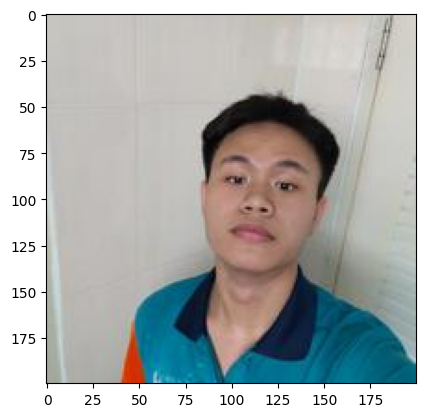

In [46]:
path = "/content/706718241_1565375888487968_7872542038581631562_n - Copy.jpg"
img = load_img(path, target_size=(200, 200))
plt.imshow(img)
plt.show()

img_array = np.array(img)

In [47]:
img_array = img_array.reshape(1, 200, 200, 3)
img_array = img_array / 255.0

prediction = np.argmax(model.predict(img_array))

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 632ms/step


In [49]:
class_indices = train_generator.class_indices
person_name = ""
for name, index in class_indices.items():
    if index == prediction:
       person_name = name
       break

print(f'Nguoi do la:{person_name}')


Nguoi do la:anh_mat_200x200
